In [2]:
!pip install xgboost

In [3]:
# 1. استيراد المكتبات الأساسية لمعالجة الجداول والعمليات الحسابية
import pandas as pd
import numpy as np

In [4]:
# 2. استيراد مكتبات الرسم البياني والتحليل Visualizations
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# 3. استيراد أدوات خوارزميات التعلم التقسيم وتقييم الأداء
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [6]:
# 4. استيراد خوارزمية الذكاء الاصطناعي الأساسية XGBoost
import xgboost as xgb

In [7]:
# 5. استيراد مكتبة حفظ النموذج النهائي لاستخدامه لاحقاً
import joblib

In [8]:
# 6. إعداد خيارات عرض الأعمدة لرؤية كافة البيانات بوضوح مستقبلاً
pd.set_option('display.max_columns', None)

In [9]:
# 7. طباعة رسالة تؤكد نجاح العملية
print("✅ تم استيراد جميع المكتبات بنجاح وجاهزون للخطوة التالية!")

✅ تم استيراد جميع المكتبات بنجاح وجاهزون للخطوة التالية!


In [10]:
#الخطوة الثانية: قراءة واستكشاف ملف البيانات (Data Loading & Initial EDA)

In [11]:
# 1. قراءة ملف البيانات وتخزينه في المتغير df
df = pd.read_csv('Tuesday-WorkingHours.pcap_ISCX.csv')

In [12]:
#الخطوة 2: التحليل الاستكشافي للبيانات (EDA)
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,88,640,7,4,440,358,220,0,62.857143,107.349008,179,0,89.5,103.345698,1246875.000,17187.500000,64.000000,135.557286,445,1,640,106.666667,194.325157,497,1,538,179.333333,303.686242,530,4,0,0,0,0,164,104,10937.500000,6250.000000,0,220,66.500000,99.001837,9801.363636,0,0,0,1,0,0,0,0,0,72.545455,62.857143,89.5,164,0,0,0,0,0,0,7,440,4,358,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.666667,132.287566,1472,0,736.0,849.859596,3937777.778,14444.444440,75.000000,192.795228,684,1,900,112.500000,252.411229,734,1,766,255.333333,435.323252,758,3,0,0,0,0,204,104,10000.000000,4444.444444,0,1472,253.142857,527.434262,278186.901100,0,0,0,1,0,0,0,0,0,272.615385,66.666667,736.0,204,0,0,0,0,0,0,9,600,4,2944,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1205,7,4,2776,2830,1388,0,396.571429,677.274651,1415,0,707.5,816.950631,4652282.158,9128.630705,120.500000,236.433336,777,1,1205,200.833333,397.058392,1008,1,927,309.000000,491.647231,876,1,0,0,0,0,164,104,5809.128631,3319.502075,0,1415,467.166667,690.098917,476236.515200,0,0,0,1,0,0,0,0,0,509.636364,396.571429,707.5,164,0,0,0,0,0,0,7,2776,4,2830,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,88,511,7,4,452,370,226,0,64.571429,110.276708,185,0,92.5,106.809800,1608610.568,21526.418790,51.100000,90.767652,299,1,511,85.166667,131.900594,349,1,462,154.000000,224.719826,412,1,0,0,0,0,164,104,13698.630140,7827.788650,0,226,68.500000,101.933579,10390.454550,0,0,0,1,0,0,0,0,0,74.727273,64.571429,92.5,164,0,0,0,0,0,0,7,452,4,370,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,773,9,4,612,2944,306,0,68.000000,134.933317,1472,0,736.0,849.859596,4600258.732,16817.593790,64.416667,148.698266,531,1,773,96.625000,196.665733,580,1,675,225.000000,348.901132,627,1,0,0,0,0,204,104,11642.949550,5174.644243,0,1472,254.000000,527.520762,278278.153800,0,0,0,1,0,0,0,0,0,273.538461,68.000000,736.0,204,0,0,0,0,0,0,9,612,4,2944,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [13]:
df.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
445904,53,155,2,2,88,120,44,44,44.0,0.0,60,60,60.0,0.0,1341935.484,25806.45161,51.666667,83.428612,148,3,3,3.0,0.0,3,3,4,4.0,0.0,4,4,0,0,0,0,64,64,12903.225810,12903.225810,44,60,50.4,8.763561,76.8,0,0,0,0,0,0,0,0,1,63.00,44.0,60.0,64,0,0,0,0,0,0,2,88,2,120,-1,-1,1,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
445905,59317,110,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000,18181.81818,110.000000,0.000000,110,110,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9090.909091,9090.909091,0,0,0.0,0.000000,0.0,0,0,0,0,1,1,0,0,1,0.00,0.0,0.0,20,0,0,0,0,0,0,1,0,1,0,64,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
445906,53,166,2,2,88,188,44,44,44.0,0.0,94,94,94.0,0.0,1662650.602,24096.38554,55.333333,90.643992,160,3,3,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0,0,0,64,64,12048.192770,12048.192770,44,94,64.0,27.386128,750.0,0,0,0,0,0,0,0,0,1,80.00,44.0,94.0,64,0,0,0,0,0,0,2,88,2,188,-1,-1,1,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
445907,54726,81,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000,24691.35802,81.000000,0.000000,81,81,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,12345.679010,12345.679010,0,0,0.0,0.000000,0.0,0,0,0,0,1,0,0,0,1,0.00,0.0,0.0,32,0,0,0,0,0,0,1,0,1,0,122,33304,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
445908,53,202,2,2,102,158,51,51,51.0,0.0,79,79,79.0,0.0,1287128.713,19801.98020,67.333333,77.151366,152,1,1,1.0,0.0,1,1,49,49.0,0.0,49,49,0,0,0,0,40,40,9900.990099,9900.990099,51,79,62.2,15.336232,235.2,0,0,0,0,0,0,0,0,1,77.75,51.0,79.0,40,0,0,0,0,0,0,2,102,2,158,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [14]:
df.sample()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
316442,56876,47,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,42553.19149,47.0,0.0,47,47,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,21276.59574,21276.59574,0,0,0.0,0.0,0.0,0,0,0,0,1,0,0,0,1,0.0,0.0,0.0,20,0,0,0,0,0,0,1,0,1,0,377,253,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445909 entries, 0 to 445908
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             445909 non-null  int64  
 1    Flow Duration                445909 non-null  int64  
 2    Total Fwd Packets            445909 non-null  int64  
 3    Total Backward Packets       445909 non-null  int64  
 4   Total Length of Fwd Packets   445909 non-null  int64  
 5    Total Length of Bwd Packets  445909 non-null  int64  
 6    Fwd Packet Length Max        445909 non-null  int64  
 7    Fwd Packet Length Min        445909 non-null  int64  
 8    Fwd Packet Length Mean       445909 non-null  float64
 9    Fwd Packet Length Std        445909 non-null  float64
 10  Bwd Packet Length Max         445909 non-null  int64  
 11   Bwd Packet Length Min        445909 non-null  int64  
 12   Bwd Packet Length Mean       445909 non-nul

In [16]:
df.shape

(445909, 79)

In [17]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,445909.000000,4.459090e+05,445909.000000,445909.000000,4.459090e+05,4.459090e+05,445909.000000,445909.000000,445909.000000,445909.000000,445909.000000,445909.000000,445909.000000,445909.000000,4.457080e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,445909.000000,445909.0,445909.0,445909.0,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,445909.000000,445909.000000,445909.000000,445909.000000,4.459090e+05,445909.000000,445909.000000,445909.000000,445909.000000,445909.000000,445909.000000,445909.0,445909.000000,445909.00000,445909.000000,445909.000000,445909.000000,4.459090e+05,445909.0,445909.0,445909.0,445909.0,445909.0,445909.0,445909.000000,4.459090e+05,445909.000000,4.459090e+05,445909.000000,445909.000000,445909.000000,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05
mean,8878.375745,1.077944e+07,11.800473,13.907212,5.302105e+02,2.186324e+04,173.346669,20.579979,48.528489,49.897094,426.185778,50.359952,170.371225,126.945652,inf,inf,8.969193e+05,1.457432e+06,3.983417e+06,1.617527e+05,1.049772e+07,1.894540e+06,1.038472e+06,3.880805e+06,1.218153e+06,9.818604e+06,1.792829e+06,8.081417e+05,3.348626e+06,1.202342e+06,0.060723,0.0,0.0,0.0,-1.502153e+05,-1.171400e+04,5.345103e+04,5.825596e+03,19.930762,465.214483,107.620046,135.258513,8.290961e+04,0.018380,0.060723,0.000336,0.242597,0.291687,0.115091,0.0,0.000339,0.68745,121.243156,48.528489,170.371225,-1.502153e+05,0.0,0.0,0.0,0.0,0.0,0.0,11.800473,5.302105e+02,13.907212,2.186163e+04,7408.452460,2792.060604,2.088341,-1.321786e+04,7.265964e+04,4.670517e+04,1.642092e+05,4.828426e+04,3.294459e+06,1.497105e+05,3.407025e+06,3.145407e+06
std,19522.889728,2.955629e+07,867.072428,1172.161547,5.676904e+03,2.625768e+06,472.450792,38.938350,113.195021,146.736325,881.676023,73.694913,311.356700,284.234647,NaN,NaN,4.250992e+06,5.771200e+06,1.342159e+07,2.852817e+06,2.942314e+07,9.512342e+06,3.817298e+06,1.340005e+07,9.269572e+06,2.861556e+07,9.459806e+06,3.505231e+06,1.273227e+07,9.205516e+06,0.238822,0.0,0.0,0.0,5.289797e+07,3.595580e+06,2.240127e+05,3.544440e+04,26.280681,946.383526,190.497397,254.194714,2.594933e+05,0.134323,0.238822,0.018338,0.428654,0.454540,0.319132,0.0,0.018399,0.53444,196.527086,113.195021,311.356700,5.289797e+07,0.0,0.0,0.0,0.0,0.0,0.0,867.072428,5.676904e+03,1172.161547,2.625473e+06,15609.495614,9744.606181,6.325197,2.666478e+06,6.205625e+05,3.601504e+05,1.049887e+06,5.649489e+05,1.258776e+07,1.982346e+06,1.293249e+07,1.240892e+07
min,0.000000,-4.000000e+00,1.000

In [18]:
df.isnull()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [19]:
df.isnull().sum()

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

In [20]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
445904     True
445905    False
445906     True
445907    False
445908    False
Length: 445909, dtype: bool

In [21]:
df.duplicated().sum()

np.int64(24065)

In [22]:
# 2. إزالة المسافات المخفية من أسماء الأعمدة لمنع خطأ KeyError
df.columns = df.columns.str.strip()

In [23]:
# 3. استكشاف توزيع وأنواع الحركة الشبكية والهجمات في عمود Label
print("\n🎯 توزيع أنواع الحركة والهجمات (أرقام مطلقة):")
print(df['Label'].value_counts())


🎯 توزيع أنواع الحركة والهجمات (أرقام مطلقة):
Label
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64


In [24]:
# 2. طباعة حجم البيانات (عدد الأسطر وعدد الأعمدة)
print(f"📊 إجمالي عدد الأسطر (حركات الشبكة): {df.shape[0]:,}")
print(f"📊 إجمالي عدد الخصائص (الأعمدة): {df.shape[1]}")

📊 إجمالي عدد الأسطر (حركات الشبكة): 445,909
📊 إجمالي عدد الخصائص (الأعمدة): 79


In [25]:
# 5. استكشاف النسبة المئوية لكل نوع من حركة الشبكة
print("\n📊 النسبة المئوية لكل نوع من حركة الشبكة:")
print(df['Label'].value_counts(normalize=True) * 100)


📊 النسبة المئوية لكل نوع من حركة الشبكة:
Label
BENIGN         96.897349
FTP-Patator     1.780184
SSH-Patator     1.322467
Name: proportion, dtype: float64


In [26]:
# 1. عرض معلومات عامة عن البيانات (أنواع الأعمدة وعدد القيم الغير فارغة)
print("ℹ️ --- أولاً: معلومات هيكل البيانات (Data Info) ---")
df.info()

ℹ️ --- أولاً: معلومات هيكل البيانات (Data Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445909 entries, 0 to 445908
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             445909 non-null  int64  
 1   Flow Duration                445909 non-null  int64  
 2   Total Fwd Packets            445909 non-null  int64  
 3   Total Backward Packets       445909 non-null  int64  
 4   Total Length of Fwd Packets  445909 non-null  int64  
 5   Total Length of Bwd Packets  445909 non-null  int64  
 6   Fwd Packet Length Max        445909 non-null  int64  
 7   Fwd Packet Length Min        445909 non-null  int64  
 8   Fwd Packet Length Mean       445909 non-null  float64
 9   Fwd Packet Length Std        445909 non-null  float64
 10  Bwd Packet Length Max        445909 non-null  int64  
 11  Bwd Packet Length Min        445909 non-null  int64  
 12  Bwd Pa

In [27]:
# 2. عرض الملخص الإحصائي لأول 5 أعمدة (المتوسط، الانحراف المعياري، الحد الأدنى والأقصى)
print("\n📈 --- ثانياً: الملخص الإحصائي لأول 5 خصائص شبكية ---")
display(df.describe().T.head(5))


📈 --- ثانياً: الملخص الإحصائي لأول 5 خصائص شبكية ---


,count,mean,std,min,25%,50%,75%,max
Destination Port,445909.0,8.878376e+03,1.952289e+04,0.0,53.0,80.0,443.0,65505.0
Flow Duration,445909.0,1.077944e+07,2.955629e+07,-4.0,186.0,31288.0,466820.0,119999977.0
Total Fwd Packets,445909.0,1.180047e+01,8.670724e+02,1.0,2.0,2.0,4.0,206446.0
Total Backward Packets,445909.0,1.390721e+01,1.172162e+03,0.0,1.0,2.0,2.0,276072.0
Total Length of Fwd Packets,445909.0,5.302105e+02,5.676904e+03,0.0,4.0,68.0,150.0,2428415.0


In [28]:
# 3. عرض أول 5 أسطر من الجدول لمعاينة شكل البيانات الفعلي
print("\n👀 --- ثالثاً: معاينة أول 5 أسطر من البيانات ---")
df.head()


👀 --- ثالثاً: معاينة أول 5 أسطر من البيانات ---


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,88,640,7,4,440,358,220,0,62.857143,107.349008,179,0,89.5,103.345698,1246875.000,17187.500000,64.000000,135.557286,445,1,640,106.666667,194.325157,497,1,538,179.333333,303.686242,530,4,0,0,0,0,164,104,10937.500000,6250.000000,0,220,66.500000,99.001837,9801.363636,0,0,0,1,0,0,0,0,0,72.545455,62.857143,89.5,164,0,0,0,0,0,0,7,440,4,358,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.666667,132.287566,1472,0,736.0,849.859596,3937777.778,14444.444440,75.000000,192.795228,684,1,900,112.500000,252.411229,734,1,766,255.333333,435.323252,758,3,0,0,0,0,204,104,10000.000000,4444.444444,0,1472,253.142857,527.434262,278186.901100,0,0,0,1,0,0,0,0,0,272.615385,66.666667,736.0,204,0,0,0,0,0,0,9,600,4,2944,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1205,7,4,2776,2830,1388,0,396.571429,677.274651,1415,0,707.5,816.950631,4652282.158,9128.630705,120.500000,236.433336,777,1,1205,200.833333,397.058392,1008,1,927,309.000000,491.647231,876,1,0,0,0,0,164,104,5809.128631,3319.502075,0,1415,467.166667,690.098917,476236.515200,0,0,0,1,0,0,0,0,0,509.636364,396.571429,707.5,164,0,0,0,0,0,0,7,2776,4,2830,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,88,511,7,4,452,370,226,0,64.571429,110.276708,185,0,92.5,106.809800,1608610.568,21526.418790,51.100000,90.767652,299,1,511,85.166667,131.900594,349,1,462,154.000000,224.719826,412,1,0,0,0,0,164,104,13698.630140,7827.788650,0,226,68.500000,101.933579,10390.454550,0,0,0,1,0,0,0,0,0,74.727273,64.571429,92.5,164,0,0,0,0,0,0,7,452,4,370,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,773,9,4,612,2944,306,0,68.000000,134.933317,1472,0,736.0,849.859596,4600258.732,16817.593790,64.416667,148.698266,531,1,773,96.625000,196.665733,580,1,675,225.000000,348.901132,627,1,0,0,0,0,204,104,11642.949550,5174.644243,0,1472,254.000000,527.520762,278278.153800,0,0,0,1,0,0,0,0,0,273.538461,68.000000,736.0,204,0,0,0,0,0,0,9,612,4,2944,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [29]:
#الرسم البياني لتوزيع حركة الشبكة والهجمات

C:\Users\hp\AppData\Local\Temp\ipykernel_6292\3948950848.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df, palette='viridis')


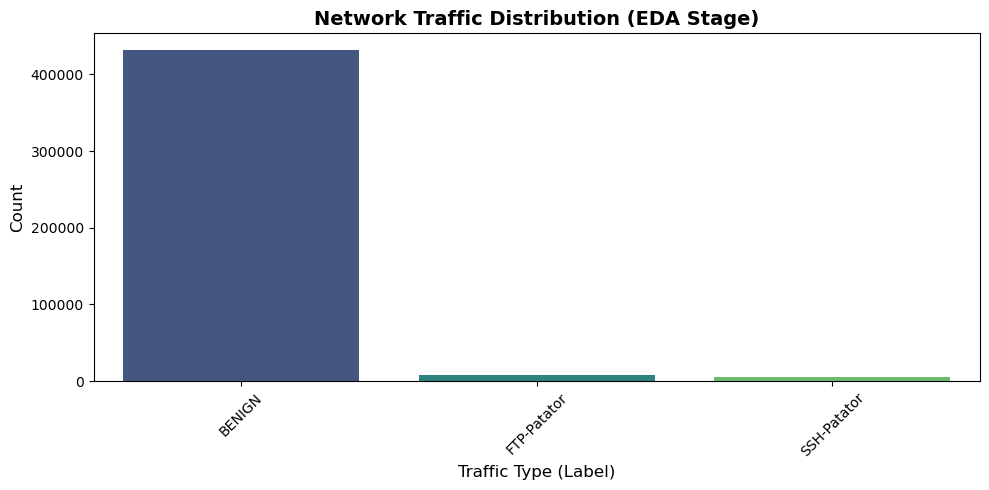

In [30]:
# 1. إنشاء شكل بياني جديد وتحديد الحجم (العرض 10 والارتفاع 5)
plt.figure(figsize=(10, 5))

# 2. رسم مخطط أعمدة لرؤية توزيع الهجمات والحركة الطبيعية
sns.countplot(x='Label', data=df, palette='viridis')

# 3. إعداد العناوين بالإنجليزية لتفادي انقسام الخط العربي ولضمان الشكل الاحترافي أمام اللجنة
plt.title('Network Traffic Distribution (EDA Stage)', fontsize=14, fontweight='bold')
plt.xlabel('Traffic Type (Label)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# 4. تدوير أسماء الفئات على المحور الأفقي لتجنب التداخل
plt.xticks(rotation=45)

# 5. ضبط مسافات الرسم وعرض الشكل البياني
plt.tight_layout()
plt.show()

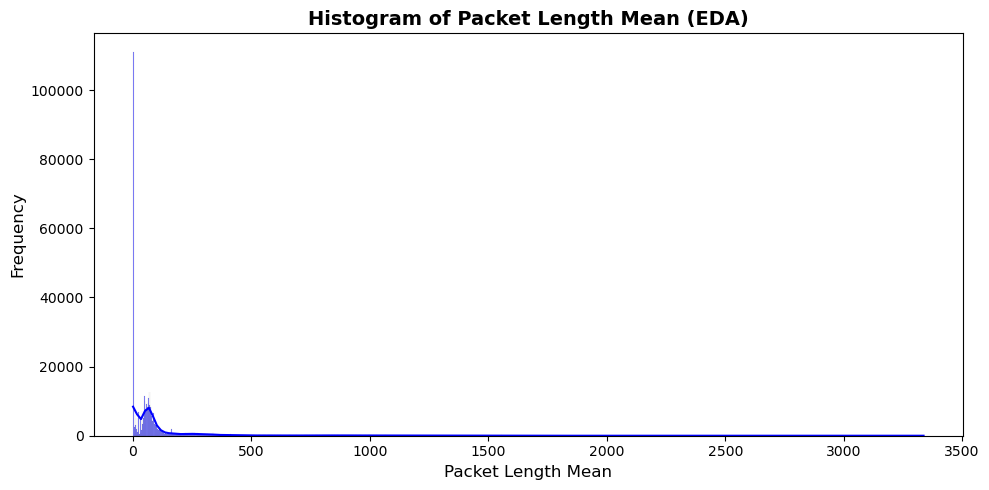

In [31]:
# 1. تحديد حجم لوحة الرسم البياني (العرض 10 والارتفاع 5)
plt.figure(figsize=(10, 5))

# 2. رسم HistPlot لتوزيع طول الحزم الشبكية (Packet Length Mean)
# هذا المخطط يوضح تكرار أطوال الحزم الشبكية ويساعد في فهم توزيع البيانات
sns.histplot(df['Packet Length Mean'], kde=True, color='blue')

# 3. إضافات وتحسينات الرسم البياني (العناوين وتسمية المحاور باللغة الإنجليزية)
# مع تعليق عربي يوضح المعنى
plt.title('Histogram of Packet Length Mean (EDA)', fontsize=14, fontweight='bold')  # عنوان: مخطط توزيع أطوال الحزم
plt.xlabel('Packet Length Mean', fontsize=12)  # محور س: طول الحزم
plt.ylabel('Frequency', fontsize=12)  # محور ص: التكرار

# 4. تحسين المسافات وعرض الرسم البياني
plt.tight_layout()
plt.show()

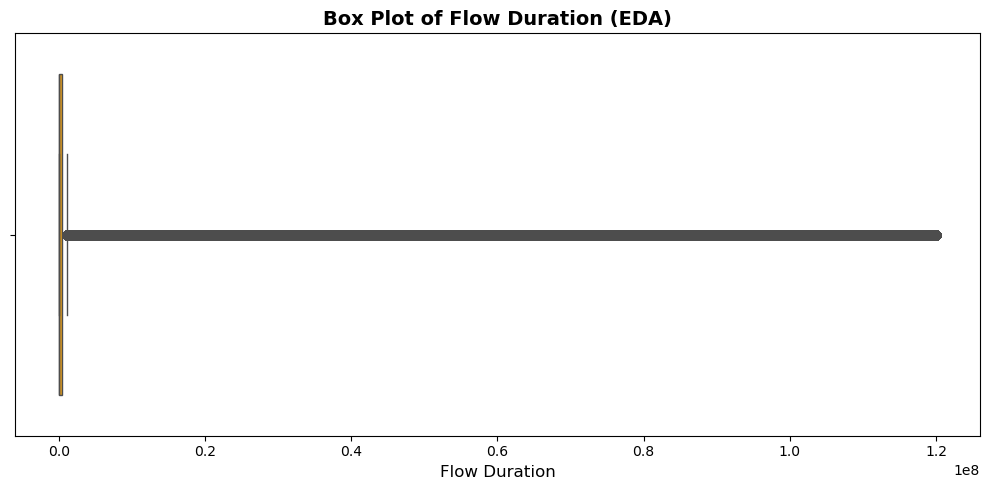

In [32]:
# 1. تحديد حجم لوحة الرسم البياني (العرض 10 والارتفاع 5)
plt.figure(figsize=(10, 5))

# 2. رسم BoxPlot لـ 'Flow Duration'
# هذا المخطط يوضح توزيع مدة الاتصال ويساعد في اكتشاف القيم الشاذة (Outliers)
sns.boxplot(x=df['Flow Duration'], color='orange')

# 3. إضافات وتحسينات الرسم البياني (العناوين وتسمية المحاور باللغة الإنجليزية)
# مع تعليق عربي يوضح المعنى
plt.title('Box Plot of Flow Duration (EDA)', fontsize=14, fontweight='bold')  # عنوان: مخطط صندوق مدة الاتصال
plt.xlabel('Flow Duration', fontsize=12)  # محور س: مدة الاتصال

# 4. تحسين المسافات وعرض الرسم البياني
plt.tight_layout()
plt.show()

In [33]:
# الخلية التالية: تشفير المتغيرات النصية (Label Encoding)

In [34]:
# 1. استيراد أداة LabelEncoder من مكتبة scikit-learn لتشفير النصوص
from sklearn.preprocessing import LabelEncoder

In [35]:
# 2. إنشاء كائن (Instance) من الأداة
le = LabelEncoder()

In [36]:
# 3. تحويل العمود النصي Label إلى أرقام وتخزينه في نفس العمود داخل DataFrame
df['Label'] = le.fit_transform(df['Label'])

In [37]:
# 4. طباعة خريطة التشفير لمعرفة كل رقم ماذا يمثل من أنواع الهجمات (مهم جداً لعرضك أمام اللجنة)
print("🔢 خريطة تشفير الفئات (كل رقم وما يقابله من نص أصلي):")
for index, class_name in enumerate(le.classes_):
    print(f"الرقم {index} -> {class_name}")

🔢 خريطة تشفير الفئات (كل رقم وما يقابله من نص أصلي):
الرقم 0 -> BENIGN
الرقم 1 -> FTP-Patator
الرقم 2 -> SSH-Patator


In [38]:
# 5. معاينة أول 5 أسطر لعمود Label للتأكد من نجاح التحويل إلى أرقام
print("\n👀 معاينة عمود Label بعد التشفير الرقمي:")
display(df[['Label']].head())


👀 معاينة عمود Label بعد التشفير الرقمي:


,Label
0,0
1,0
2,0
3,0
4,0


In [39]:
#الخطوة 4: تنظيف البيانات (Data Cleaning)

In [40]:
import numpy as np

# 1. معرفة عدد الأسطر قبل عملية التنظيف
rows_before = df.shape[0]
print(f"📊 عدد الأسطر قبل التنظيف: {rows_before:,}")

# 2. استبدال القيم غير المنتهية (np.inf و -np.inf) بقيم فارغة (np.nan) لتسهيل التعامل معها
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3. حساب وحذف جميع الأسطر التي تحتوي على قيم فارغة (NaN)
nan_count = df.isna().sum().sum()
print(f"🔍 عدد القيم الفارغة/غير المنتهية المكتشفة: {nan_count:,}")

df.dropna(inplace=True)

# 4. معرفة عدد الأسطر بعد التنظيف وحساب الأسطر المحذوفة
rows_after = df.shape[0]
print(f"✅ عدد الأسطر بعد التنظيف: {rows_after:,}")
print(f"🧹 تم حذف {rows_before - rows_after:,} سطر ملوث بنجاح.")

# 5. التأكد النهائي: فحص وجود أي قيمة فارغة متبقية في البيانات
remaining_nans = df.isna().sum().sum()
print(f"🎯 التأكد النهائي - إجمالي القيم الفارغة المتبقية: {remaining_nans}")

📊 عدد الأسطر قبل التنظيف: 445,909
🔍 عدد القيم الفارغة/غير المنتهية المكتشفة: 528
✅ عدد الأسطر بعد التنظيف: 445,645
🧹 تم حذف 264 سطر ملوث بنجاح.
🎯 التأكد النهائي - إجمالي القيم الفارغة المتبقية: 0


In [41]:
import numpy as np

In [42]:
# 1. معرفة عدد الأسطر قبل عملية التنظيف
rows_before = df.shape[0]
print(f"📊 عدد الأسطر قبل التنظيف: {rows_before:,}")

📊 عدد الأسطر قبل التنظيف: 445,645


In [43]:
# 2. استبدال القيم غير المنتهية (np.inf و -np.inf) بقيم فارغة (np.nan) لتسهيل التعامل معها
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [44]:
# 3. حساب وحذف جميع الأسطر التي تحتوي على قيم فارغة (NaN)
nan_count = df.isna().sum().sum()
print(f"🔍 عدد القيم الفارغة/غير المنتهية المكتشفة: {nan_count:,}")

🔍 عدد القيم الفارغة/غير المنتهية المكتشفة: 0


In [45]:
df.dropna(inplace=True)

In [46]:
# 4. معرفة عدد الأسطر بعد التنظيف وحساب الأسطر المحذوفة
rows_after = df.shape[0]
print(f"✅ عدد الأسطر بعد التنظيف: {rows_after:,}")
print(f"🧹 تم حذف {rows_before - rows_after:,} سطر ملوث بنجاح.")

✅ عدد الأسطر بعد التنظيف: 445,645
🧹 تم حذف 0 سطر ملوث بنجاح.


In [47]:
# 5. التأكد النهائي: فحص وجود أي قيمة فارغة متبقية في البيانات
remaining_nans = df.isna().sum().sum()
print(f"🎯 التأكد النهائي - إجمالي القيم الفارغة المتبقية: {remaining_nans}")

🎯 التأكد النهائي - إجمالي القيم الفارغة المتبقية: 0


In [49]:
df.isna().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64

In [50]:
df.duplicated().sum()

np.int64(24019)

In [53]:
# 1. معرفة عدد الأسطر قبل حذف المكررات
rows_before_dup = df.shape[0]

In [54]:
# 2. حذف جميع الأسطر المكررة نهائياً
df.drop_duplicates(inplace=True)

In [55]:
# 3. معرفة عدد الأسطر بعد حذف المكررات
rows_after_dup = df.shape[0]

In [58]:
# 4. طباعة التقرير النهائي على الشاشة (هذا السطر هو من يظهر المخرج)
print(f"🧹 عدد الأسطر المحذوفة بسبب التكرار: {rows_before_dup - rows_after_dup:,}")
print(f"✅ إجمالي الأسطر النظيفة والجاهزة للتدريب: {rows_after_dup:,}")
print(f"🎯 التأكد من المكررات المتبقية: {df.duplicated().sum()}")

🧹 عدد الأسطر المحذوفة بسبب التكرار: 24,019
✅ إجمالي الأسطر النظيفة والجاهزة للتدريب: 421,626
🎯 التأكد من المكررات المتبقية: 0


In [59]:
# 1. معرفة عدد الأسطر قبل حذف المكررات
rows_before_dup = df.shape[0]
print(f"🧹 عدد الأسطر المحذوفة بسبب التكرار: {rows_before_dup - rows_after_dup:,}")

🧹 عدد الأسطر المحذوفة بسبب التكرار: 0


In [62]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
445902    False
445903    False
445905    False
445907    False
445908    False
Length: 421626, dtype: bool

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
# 1. طباعة عدد الأسطر وعدد الأعمدة باستخدام df.shape
print(f"📊 إجمالي عدد الأسطر (السجلات): {df.shape[0]:,}")
print(f"📐 إجمالي عدد الأعمدة (الخصائص): {df.shape[1]}")

📊 إجمالي عدد الأسطر (السجلات): 421,626
📐 إجمالي عدد الأعمدة (الخصائص): 79


In [65]:
# 2. طباعة ملخص شامل لأبعاد البيانات
print(f"\nDimensions (Rows, Columns): {df.shape}")


Dimensions (Rows, Columns): (421626, 79)


In [66]:
#الخطوة 5: تقسيم البيانات (Train/Test Split)

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
# 1. فصل الخصائص (Features) عن عمود الهدف (Label)
X = df.drop(columns=['Label'])
y = df['Label']

In [69]:
# 2. تقسيم البيانات إلى 80% تدريب و 20% اختبار مع مراعاة التوازن الطبقي (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

In [70]:
# 3. طباعة تقرير أحجام المجموعات بعد التقسيم
print("📊 أبعاد مجموعات البيانات بعد التقسيم:")
print(f"🏋️ مجموعة التدريب (X_train): {X_train.shape[0]:,} سطر | {X_train.shape[1]} ميزة")
print(f"🧪 مجموعة الاختبار (X_test):  {X_test.shape[0]:,} سطر | {X_test.shape[1]} ميزة")

📊 أبعاد مجموعات البيانات بعد التقسيم:
🏋️ مجموعة التدريب (X_train): 337,300 سطر | 78 ميزة
🧪 مجموعة الاختبار (X_test):  84,326 سطر | 78 ميزة


In [72]:
#الخطوة 6: تدريب النموذج (XGBoost Training)

In [73]:
from xgboost import XGBClassifier
import time

In [74]:
# 1. إنشاء كائن النموذج وتحديد الملاحظات الرئيسية
model = XGBClassifier(
    n_estimators=100,       # عدد الأشجار
    learning_rate=0.1,      # معدل التعلم
    random_state=42,        # لضمان ثبات النتائج
    n_jobs=-1               # استخدام جميع معالجات الجهاز للسرعة
)

In [75]:
# 2. بدء حساب وقت التدريب
start_time = time.time()

print("⏳ جاري تدريب النموذج على مجموعة التدريب (X_train)...")
model.fit(X_train, y_train)

end_time = time.time()
training_duration = end_time - start_time

⏳ جاري تدريب النموذج على مجموعة التدريب (X_train)...


In [76]:
# 3. طباعة تأكيد النجاح ووقت استغراق التدريب
print("✅ تم تدريب نموذج XGBoost بنجاح!")
print(f"⏱️ الوقت المستغرق في التدريب: {training_duration:.2f} ثانية")

✅ تم تدريب نموذج XGBoost بنجاح!
⏱️ الوقت المستغرق في التدريب: 7.32 ثانية


In [80]:
#الخطوة 7: تقييم النموذج واختبار أدائه (Model Evaluation)

In [81]:
from sklearn.metrics import accuracy_score, classification_report

In [82]:
# 1. جعل النموذج يتنبأ على بيانات الاختبار التي لم يرها من قبل
y_pred = model.predict(X_test)

In [83]:
# 2. حساب نسبة الدقة الإجمالية (Accuracy)
acc = accuracy_score(y_test, y_pred)
print(f"🎯 نسبة الدقة الإجمالية للنموذج (Accuracy): {acc * 100:.2f}%\n")

🎯 نسبة الدقة الإجمالية للنموذج (Accuracy): 100.00%



In [84]:
#الخلية 12: رسم مصفوفة الارتباك (Confusion Matrix)

In [85]:
from sklearn.metrics import confusion_matrix

In [86]:
import matplotlib.pyplot as plt

In [87]:
import seaborn as sns

In [88]:
# 1. حساب مصفوفة الارتباك
cm = confusion_matrix(y_test, y_pred)

<Axes: >

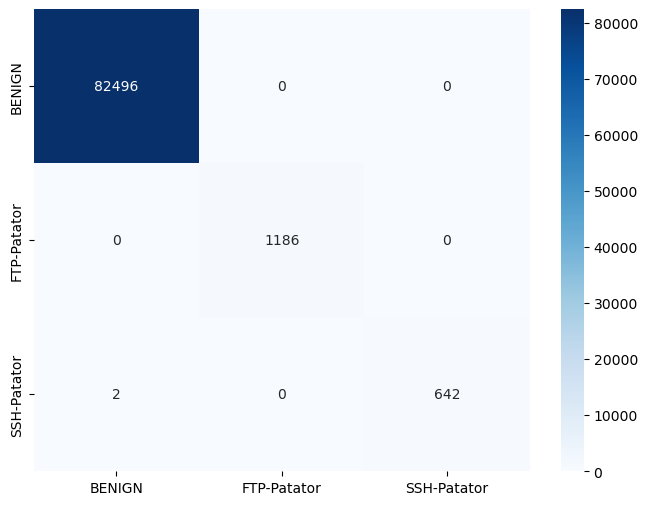

In [89]:
# 2. رسم المصفوفة بصرياً
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)

In [92]:
from sklearn.metrics import accuracy_score

# حساب الدقة بدقة كاملة
acc = accuracy_score(y_test, y_pred)

print(f"🎯 الدقة بنسبة مئوية ممتدة: {acc * 100:.6f}%")
print(f"📊 القيمة العشرية الخام: {acc}")

🎯 الدقة بنسبة مئوية ممتدة: 99.997628%
📊 القيمة العشرية الخام: 0.9999762825225909


In [93]:
#رسم أهم 10 ميزات شبكية لـ XGBoost

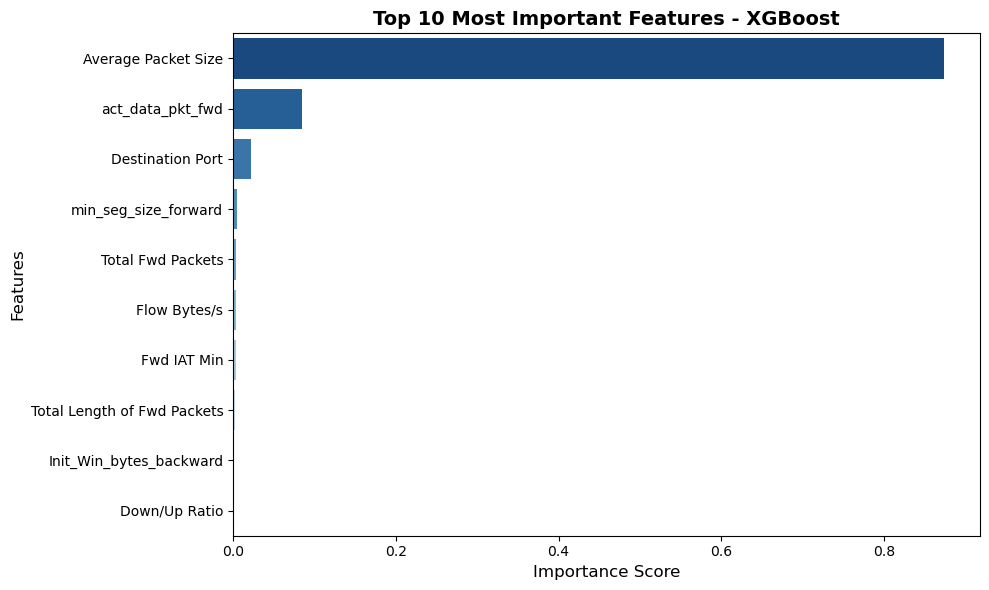

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. استخراج أهمية الميزات من نموذج XGBoost
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# 2. ترتيب أعلى 10 ميزات تأثيراً في اتخاذ القرار
top_10_features = feature_importances.nlargest(10)

# 3. رسم الميزات الأعلى بطريقة توافقية بدون تحذيرات
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_10_features.values, 
    y=top_10_features.index, 
    hue=top_10_features.index, 
    palette='Blues_r', 
    legend=False
)

# 4. إضافة العناوين والمحاور
plt.title('Top 10 Most Important Features - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

In [98]:
#الخطوة 9: تصدير وحفظ النموذج (Model Export)

In [99]:
import joblib

In [100]:
# 1. حفظ نموذج XGBoost المدرب
joblib.dump(model, 'xgboost_ids_model.pkl')

['xgboost_ids_model.pkl']

In [101]:
# 2. حفظ الـ Label Encoder لاستخدامه عند التنبؤ ببيانات جديدة
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [102]:
print("✅ تم تصدير وحفظ النموذج والمشفر بنجاح!")

✅ تم تصدير وحفظ النموذج والمشفر بنجاح!


In [103]:
# الرفع على الإستضااااافة 

In [104]:
!pip install streamlit pandas numpy joblib plotly